In [7]:
import sys
sys.path.extend(['/home/zhaoy/packages/Pyramid']) 
#sys.path.extend(['/Users/fzheng/SkyDrive/Codes/Python/Pyramid']) # where Pyramid situates
print('Python %s on %s' % (sys.version, sys.platform))

import cv2
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt 
%matplotlib inline
import hyperspy.api as hs
import pyramid as pr
import os
from tqdm import tqdm_notebook as tqdm
from scipy.ndimage import gaussian_filter, rotate, binary_dilation, shift
pr.plottools.pretty_plots()
import h5py

Python 3.5.6 |Anaconda, Inc.| (default, Jun  4 2021, 13:57:47) 
[GCC 7.5.0] on linux


Create a square mask to remove phase edges

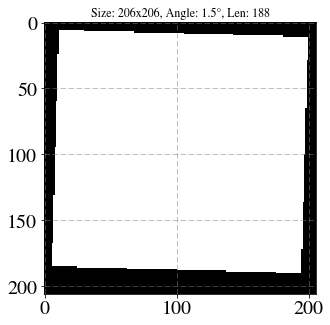

In [8]:
def create_rotated_mask(
    img_shape=(206, 206), 
    center=(103, 103), 
    length=180, 
    width=20, 
    angle=30):
  
    mask = np.zeros(img_shape, dtype=np.uint8)

    rect = (center, (length, width), angle)

    box = cv2.boxPoints(rect)
    box = np.int0(box) 
    cv2.drawContours(mask, [box], 0, 1, -1)
    
    return mask

H, W = 206, 206
center_x, center_y = 103, 98    
line_len = 188
line_width = 178  
rotate_angle = 1.5 

rect_mask = create_rotated_mask(
    img_shape=(H, W),
    center=(center_x, center_y),
    length=line_len,
    width=line_width,
    angle=rotate_angle
)

plt.figure(figsize=(5, 5))
plt.imshow(rect_mask, cmap='gray')
plt.title("Size: {}x{}, Angle: {}°, Len: {}".format(H, W, rotate_angle, line_len))
plt.grid(True, which='both', color='gray', linestyle='--', linewidth=0.5)
plt.show()

pm shape: (194, 204)
pm shape: (194, 204)
pm shape: (194, 204)
pm shape: (194, 204)
pm shape: (194, 204)
pm shape: (194, 204)
pm shape: (194, 204)
pm shape: (194, 204)


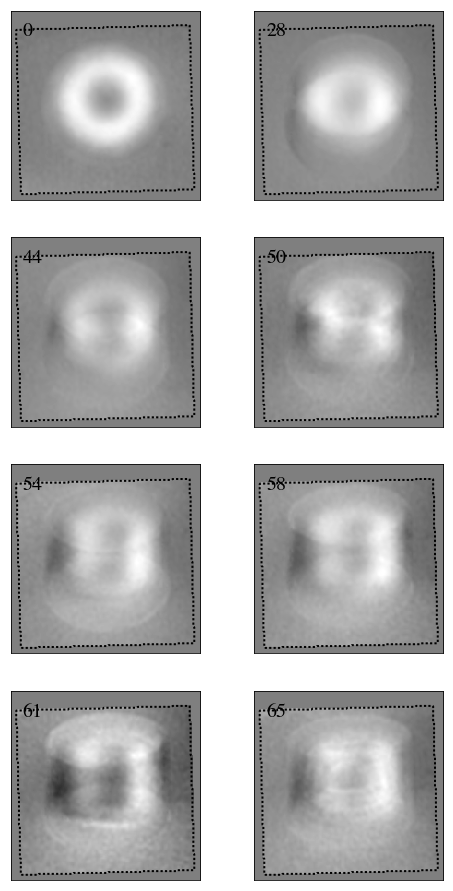

In [9]:
angles = [0,28,44,50,54,58,61,65]
fig = plt.figure(figsize=(8,16))
ax = {}
magdata = hs.load('/home/zhaoy/studio/target-skyrmion/dataset/dm3_refin/refin_Mag_alg_roted-aligned (Manually Aligned)_t_f_off.dm3')

l = 0  
h = 0  
phasemaps = []
for i, angle in enumerate(angles):
    tilt = angle
    maskdata = rect_mask#[i]
    pm = magdata.inav[i].data
    print("pm shape: {}".format(pm.shape))
    padded_pm = np.pad(pm, 
                        pad_width=((6, 6), (1, 1)),  # (y_top, y_bottom), (x_left, x_right)
                        mode='edge')  
    
    vert_pm = padded_pm.copy()
    if l != 0:
        vert_pm = np.zeros_like(padded_pm) 
        if l > 0: 
            vert_pm[:-l, :] = padded_pm[l:, :]
            vert_pm[-l:, :] = padded_pm[-l:, :]
        elif l < 0:  
            l_abs = abs(l)
            vert_pm[l_abs:, :] = padded_pm[:-l_abs, :]
            vert_pm[:l_abs, :] = padded_pm[:l_abs, :] 
    shifted_pm = vert_pm.copy() 
    if h != 0:
        shifted_pm = np.zeros_like(vert_pm) 
        if h > 0:  
            shifted_pm[:, :-h] = vert_pm[:, h:]  
            shifted_pm[:, -h:] = vert_pm[:, -h:]
        elif h < 0:  
            h_abs = abs(h)
            shifted_pm[:, h_abs:] = vert_pm[:, :-h_abs] 
            shifted_pm[:, :h_abs] = vert_pm[:, :h_abs]
    pm = shifted_pm
    mask = maskdata#.data

    phasemaps.append(pr.PhaseMap(a=1, phase=pm*mask, mask=mask))
    ax[i+1] = fig.add_subplot(4, 2, i+1, aspect='equal')
    ax[i+1].get_xaxis().set_visible(False)
    ax[i+1].get_yaxis().set_visible(False)
    phasemaps[i].plot_phase(axis=ax[i+1],scalebar=False,note="{}".format(np.abs(tilt)),cbar=False,cmap='gray',show_mask=True)

Project 3D mask and align with phase

In [10]:
def process_and_project_mask(file_path, threshold=0.5, rotation_angle=0, dilation_iter=1):
    s = hs.load(file_path)
    data = s.data.transpose((2, 1, 0))

    mask = data > threshold
    mask_int = mask.astype(np.int8)

    rotated_mask = rotate(
        mask_int, 
        angle=-1*rotation_angle, 
        axes=(1, 2), 
        reshape=False, 
        order=0, 
        mode='constant', 
        cval=0
    )

    projection = np.max(rotated_mask, axis=2)
    projection = np.rot90(projection, k=1)  
    if dilation_iter > 0:
        projection = binary_dilation(projection, iterations=dilation_iter) 
        projection = projection.astype(np.float32) 
    projection_final = projection.astype(np.float32)
    s_out = hs.signals.Signal2D(projection_final)

    orig_y = s.axes_manager[1]
    orig_x = s.axes_manager[2]

    s_out.axes_manager[0].name = orig_x.name
    s_out.axes_manager[0].scale = orig_x.scale
    s_out.axes_manager[0].offset = orig_x.offset
    s_out.axes_manager[0].units = orig_x.units

    s_out.axes_manager[1].name = orig_y.name
    s_out.axes_manager[1].scale = orig_y.scale
    s_out.axes_manager[1].offset = orig_y.offset
    s_out.axes_manager[1].units = orig_y.units
    return s_out

if __name__ == "__main__":
    input_path = '/home/zhaoy/studio/target-skyrmion/dataset/dm3_refin/3dmask.dm3'
    
    rotation_angles = [0, 28, 44, 50, 54, 58, 61, 65.2]
    geo_masks = []
    for rotation_angle in rotation_angles:
        mask = process_and_project_mask(input_path, threshold=0.5, rotation_angle=rotation_angle)
        geo_masks.append(mask)

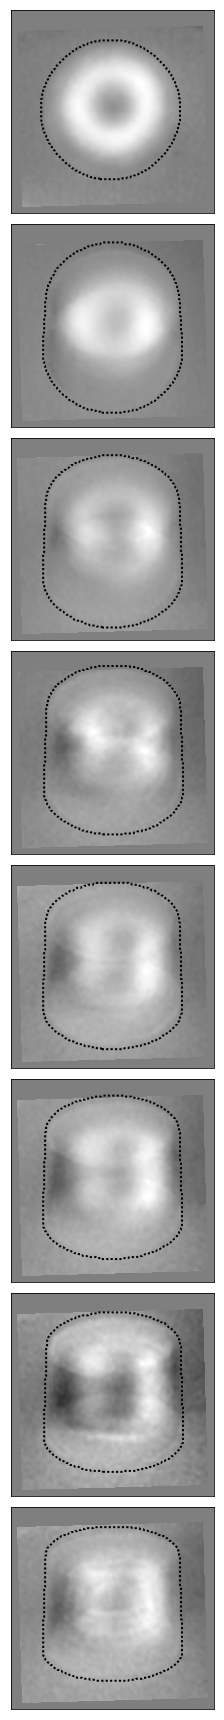

In [11]:
angles = [0, 28, 44, 50, 54, 58, 61, 65]
fig2 = plt.figure(figsize=(12,24))
ax2 = {}
phasemaps2 = []

# l > 0 down, l < 0 up
# h > 0 right, h < 0 left
for i in range (len(angles)):
    if i == 7:
        l = 5
        h = 0  
    elif i == 6:
        l = 3
        h = 1
    elif i == 5:
        l = 4
        h = 0
    elif i ==4:
        l = 2
        h = 0
    elif i == 3:
        l = 4
        h = 1
    elif i == 2:
        l = -1
        h = 0
    elif i == 1:
        l = -1
        h = 0
    elif i == 0:
        l = 2
        h = -2

    pm = phasemaps[i].phase  
    maskdata = geo_masks[i] 

    tilt = angles[i]

    shifted_maskdata = shift(maskdata, shift=[l, h], order=0, mode='constant', cval=0)

    maskdata = shifted_maskdata
    pm = phasemaps[i].phase

    phasemaps2.append(pr.PhaseMap(a=1, phase=pm, mask=maskdata))
    ax2[i+1] = fig2.add_subplot(8, 1, i+1, aspect='equal')
    ax2[i+1].get_xaxis().set_visible(False)
    ax2[i+1].get_yaxis().set_visible(False)
    phasemaps2[i].plot_phase(axis=ax2[i+1],scalebar=False,note="{}".format(''),cbar=False,show_mask=True,cmap='gray')
    plt.tight_layout(h_pad=0.4)


In [12]:
data_to_save = []
for i in range(len(angles)):
    save_item = {
            'data': phasemaps2[i].phase,            
            'mask': phasemaps2[i].mask,           
            'alpha': angles[i],    
            'beta': 0.0,             
            'gamma': 0.0              
        }
    data_to_save.append(save_item)

    output_path = 'phasemap_{:g}.pth'.format(angles[i])
    torch.save(data_to_save, output_path)